## Part (c) :

# Import, parameters and system

In [16]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
mu_max = 0.2       # 1/h
Ks = 0.5           # g/L
KI = 50            # g/L
Yxs = 0.3          # g/g
qp = 0.08          # g/g/h
F = 50             # L/h
S_feed = 100       # g/L
V0 = 200           # L (initial volume)
Vmax = 800         # L (max tank volume)
Vremove = 600      # L (removed each cycle)

# Modified Monod equation 
def mu(S):
    return mu_max * S / (Ks + S + S**2 / KI)

# system of ODE from part (a)
def system(t, y):
    X, S, P, V = y
    mu_val = mu(S)
    dVdt = F
    dXdt = mu_val * X - (F / V) * X
    dSdt = (F / V) * (S_feed - S) - (1 / Yxs) * mu_val * X
    dPdt = qp * X - (F / V) * P
    return [dXdt, dSdt, dPdt, dVdt]

# Simulation over 10 cycles

In [17]:

t_total = []
X_total = []
S_total = []
t_offset = 0
product_removed = 0

# Initial conditions
X0 = 30       # g/L
S0 = 0        # g/L
P0 = 0        # g/L
V_init = V0   # L

for cycle in range(10):
    # Time needed to reach 800 L
    t_cycle = (Vmax - V_init) / F
    
    sol = solve_ivp(system, [0, t_cycle], [X0, S0, P0, V_init], max_step=0.1)
    
    t = sol.t + t_offset
    X = sol.y[0]
    S = sol.y[1]
    P = sol.y[2]
    V = sol.y[3]
    
    # Store results
    t_total.extend(t)
    X_total.extend(X)
    S_total.extend(S)
    
    # Product removed at the end of the cycle
    P_end = P[-1]
    product_removed += P_end * Vremove / 1000  # kg
    
    # Reset after removing 600 L
    X0 = X[-1]
    S0 = S[-1]
    P0 = P[-1]
    V_init = V0   
    
    # Update time offset
    t_offset = t[-1]

# Plot

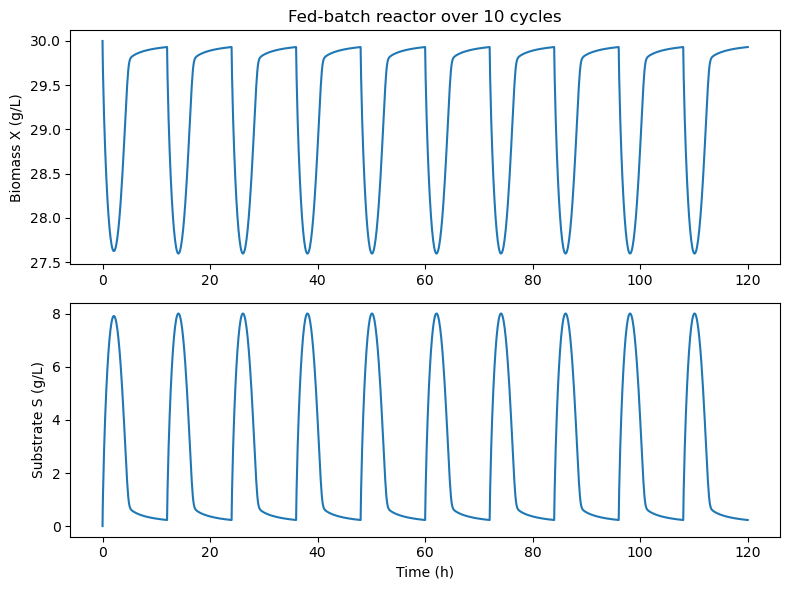

In [18]:
plt.figure(figsize=(8,6))
plt.subplot(2,1,1)
plt.plot(t_total, X_total)
plt.ylabel("Biomass X (g/L)")
plt.title("Fed-batch reactor over 10 cycles")
plt.subplot(2,1,2)
plt.plot(t_total, S_total)
plt.ylabel("Substrate S (g/L)")
plt.xlabel("Time (h)")
plt.tight_layout()
plt.show()

# Mass of product removed 

In [19]:
print("Total product removed over 10 cycles =", product_removed, "kg")

Total product removed over 10 cycles = 136.8731177800129 kg


## Part (f) :

# Definition of the function

In [ ]:
def production_rate_after_10_cycles(S_feed):

    def system_f(t, y):
        X, S, P, V = y
        mu_val = mu(S) 
        dVdt = F
        dXdt = mu_val * X - (F / V) * X
        dSdt = (F / V) * (S_feed - S) - (1 / Yxs) * mu_val * X
        dPdt = qp * X - (F / V) * P
        return [dXdt, dSdt, dPdt, dVdt]

    # Initial conditions (same as part c)
    X0 = 30
    S0 = 0
    P0 = 0
    V_init = V0

    for cycle in range(10):
        t_cycle = (Vmax - V_init) / F

        sol = solve_ivp(system_f, [0, t_cycle], [X0, S0, P0, V_init], max_step=0.1)

        X = sol.y[0]
        S = sol.y[1]
        P = sol.y[2]
        V = sol.y[3]

        # reset after each cycle
        X0 = X[-1]
        S0 = S[-1]
        P0 = P[-1]
        V_init = V0

    # product removed during 10th cycle
    P_end = P[-1]
    mass_removed = P_end * Vremove / 1000  # kg

    # cycle time (constant)
    t_cycle = (Vmax - V0) / F  # = 12 h

    return mass_removed / t_cycle  # kg/h

S_feed_values = np.linspace(10, 160, 80)
production_rates = []

for S_val in S_feed_values:
    production_rates.append(production_rate_after_10_cycles(S_val))

# Plot

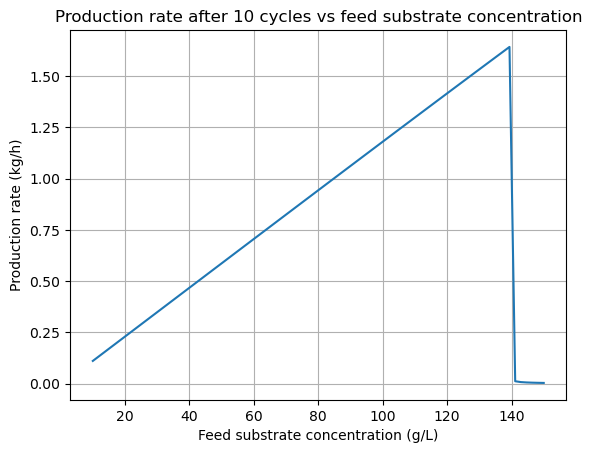

In [21]:
plt.figure()
plt.plot(S_feed_values, production_rates)
plt.xlabel("Feed substrate concentration (g/L)")
plt.ylabel("Production rate (kg/h)")
plt.title("Production rate after 10 cycles vs feed substrate concentration")
plt.grid()
plt.show()

# Optimal values

In [22]:
idx_max = np.argmax(production_rates)
print("Maximum production rate =", production_rates[idx_max], "kg/h")
print("Optimal S_feed =", S_feed_values[idx_max], "g/L")

Maximum production rate = 1.6420724001926577 kg/h
Optimal S_feed = 139.36708860759492 g/L
